# Installing and Using the bagelR Package

## Installing bagelR

The **bagelR** package can be installed via an interactive **R** session using the following code.

In [1]:
if(system.file(package = "bagelR") != "")
    {
      remove.packages("bagelR")
    }
library("remotes")
install_github("grosed/bagel/bagelR",force=TRUE)

Removing package from ‘/home/grosed/DASS/R-packages’
(as ‘lib’ is unspecified)




Running `R CMD build`...



* checking for file ‘/tmp/RtmpBSVSgS/remotes4dc0916a267ec/grosed-bagel-f62c36a/bagelR/DESCRIPTION’ ... OK
* preparing ‘bagelR’:
* checking DESCRIPTION meta-information ... OK
* cleaning src
* installing the package to process help pages
* saving partial Rd database
* cleaning src
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* building ‘bagelR_1.5.0.tar.gz’


Installing package into ‘/home/grosed/DASS/R-packages’
(as ‘lib’ is unspecified)



## Check package version

In [2]:
packageVersion("bagelR")

[1] ‘1.5.0’

## Using bagelR - 1 : Detecting Change in Mean

#### Load the bagel package

In [3]:
library(bagelR)


Attaching package: ‘bagelR’


The following objects are masked from ‘package:stats’:

    time, update




### Example 1 - no change

#### Define the feature vector function 

These functions for the **feature vector** and the **prior** correspeond to example 1 in "**Bagel : A Fast Baysian Online Changepoint Detection Algorithm for Linear Models**" *Fearnhead et al.*

In [4]:
feature_vector <- function(t,tau)
{
  if(tau == 0)
  {
    M <- matrix(c(0),nc=1,nr=1)       
    M[1,1] <- 1
    return(M)
  }
  else
  {
    M <- matrix(c(0),nc=1,nr=2)       
    M[1,1] <- 1
    if(t > tau)
    {
      M[2,1] <- 1
    }
    return(M)
  }
}

#### Define the prior function

In [5]:

prior <- function(t)
{
  mu1 <- 1;
  delta <- c(5,1)
  if(t == 1)
  {
    mu <- matrix(c(mu1),nc=1,nr=1)
    sigma <- delta[1]*diag(1)
    return(list("mu" = mu,"sigma" = sigma))
  }
  mu <- matrix(c(mu1,0),nc=1,nr=2)
  sigma <- diag(delta)
  return(list("mu" = mu,"sigma" = sigma))
}

#### Define the transform function

In [6]:
transform <- function(tau)
{
	return(matrix(c(1,1),1,2,byrow=TRUE))
}

#### Generate some data - no change

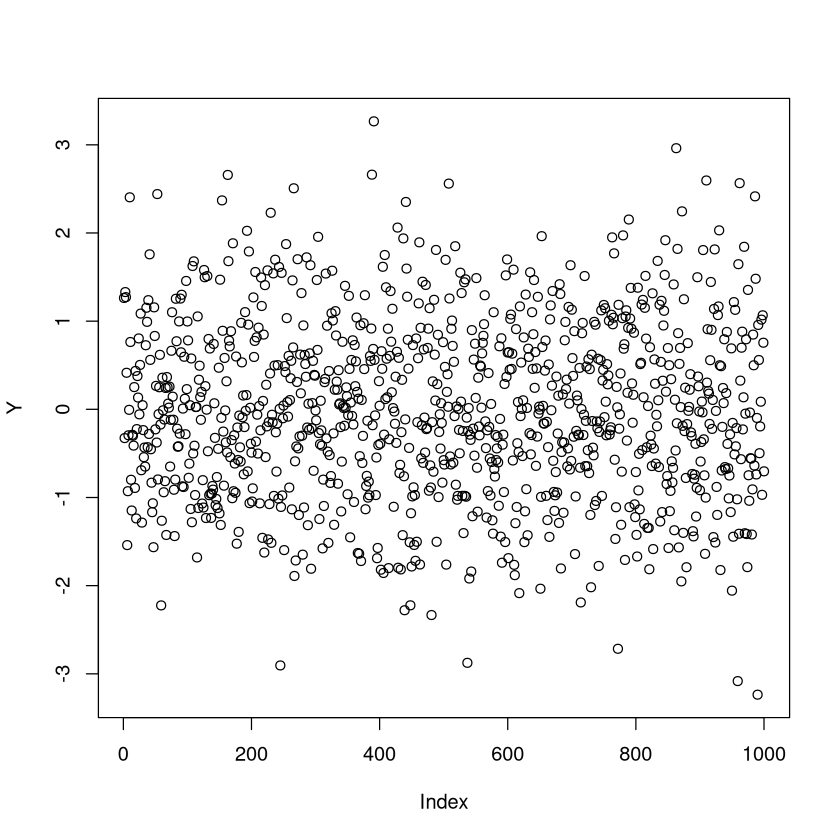

In [7]:
set.seed(0)
Y <- rnorm(1000,0,1)
plot(Y)

#### Set model parameters 

In [8]:
p <- 1.0;
p0 <- 0.9;
noise_sd <- 1.0;
max_particles <- 200
threshold <- 0.8

#### Offline analysis - known variance

**Note** - _exact_ variation can be used since analysis is _univariate_ with _known variance_

In [9]:
results <- bagel_kv_exact(Y,feature_vector,prior,transform,p0,p,noise_sd,max_particles,threshold)

#### Check for a changepoint

In [10]:
changepoint(results)

[1] NA

#### Visualise weight at tau = 0

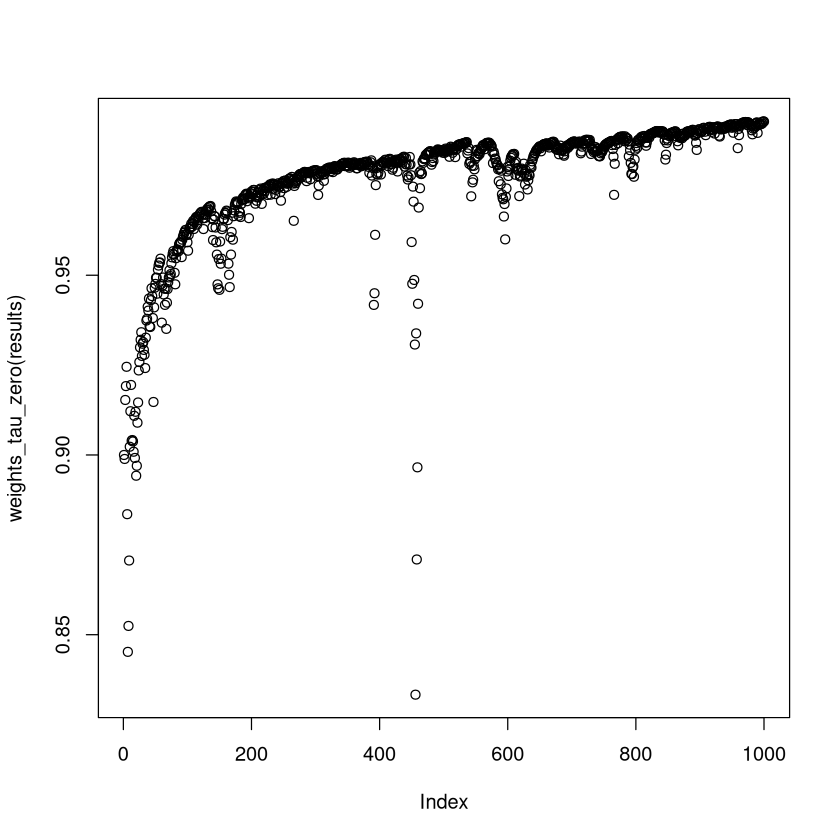

In [11]:
plot(weights_tau_zero(results))

#### Offline analysis - uknown variance

In [12]:
nu <- 1.0
iota <- 1.0

In [13]:
results <- bagel_uv_approximate(Y,feature_vector,prior,transform,p0,p,nu,iota,max_particles,threshold)

#### Check for a changepoint

In [14]:
changepoint(results)

[1] NA

#### Visualise weight at tau = 0

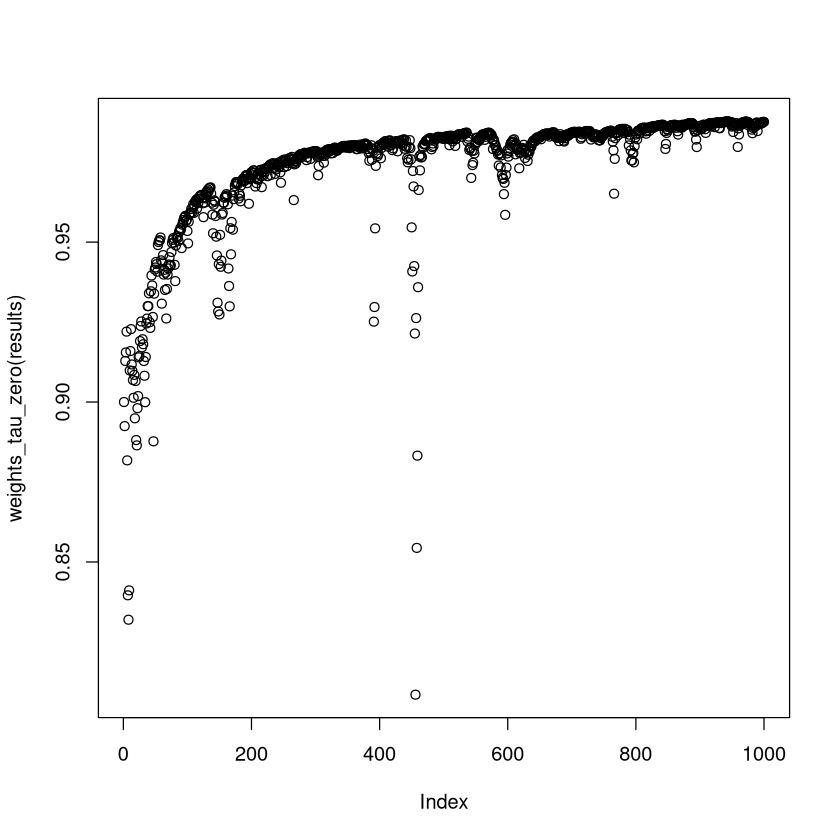

In [15]:
plot(weights_tau_zero(results))

### Example 2 - single change in mean

#### Generate some data - change at t = 501 

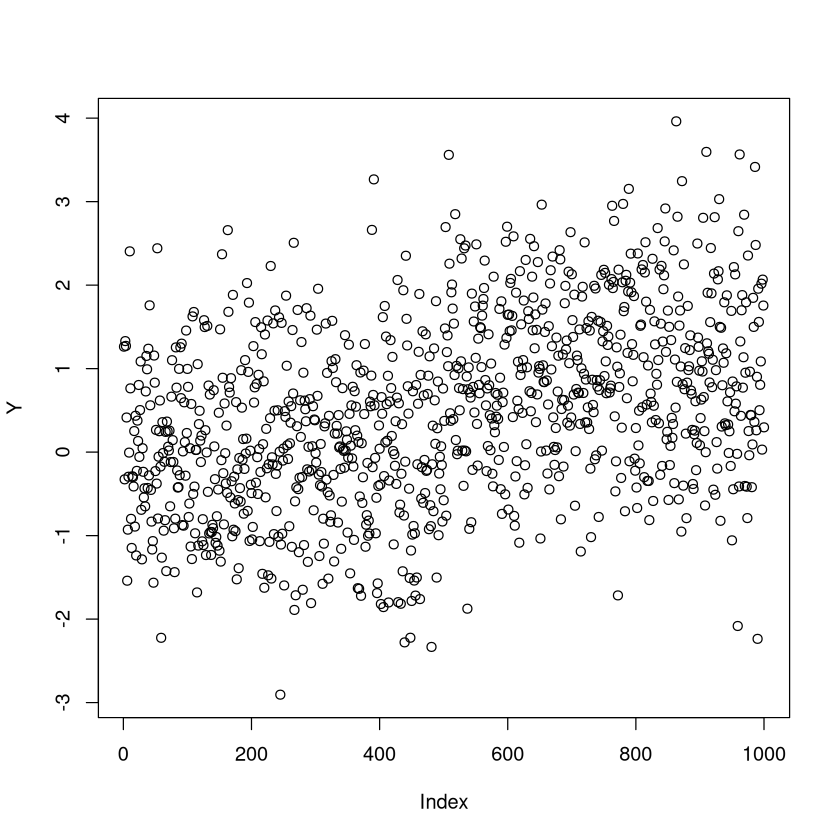

In [16]:
set.seed(0)
Y <- c(rnorm(500,0,1),rnorm(500,1,1))
plot(Y)

#### Offline analysis - known variance

**Note** - _exact_ variation can be used since analysis is _univariate_ with _known variance_

In [17]:
results <- bagel_kv_exact(Y,feature_vector,prior,transform,p0,p,noise_sd,max_particles,threshold)

#### Check for a changepoint

In [18]:
changepoint(results)

$location
[1] 501

$detected
[1] 513

#### Visualise weight at tau = 0

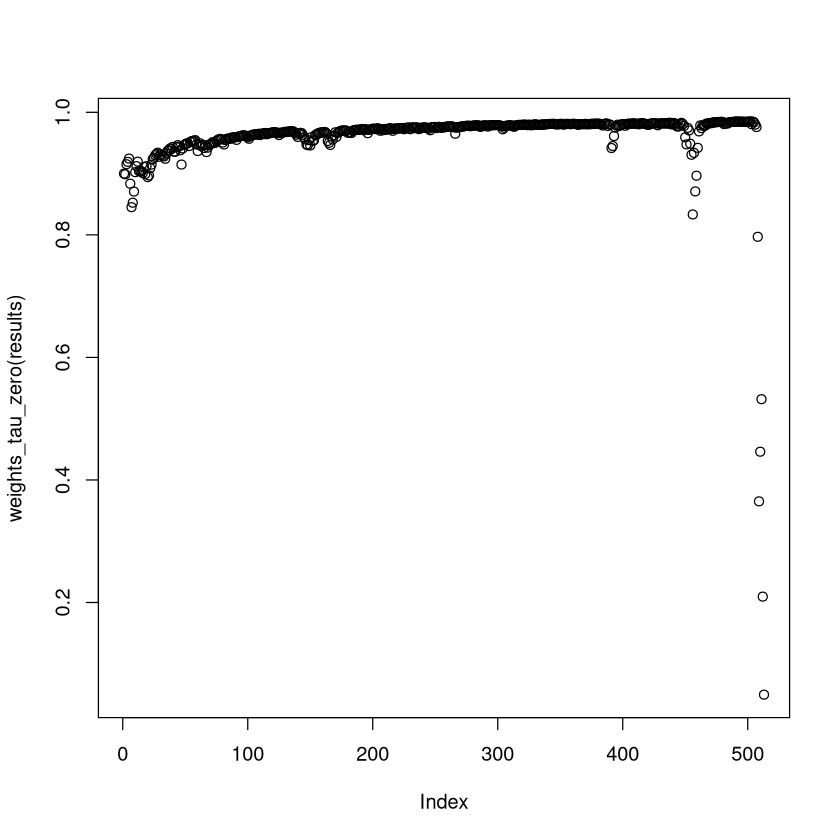

In [19]:
plot(weights_tau_zero(results))

#### Plot weights in region of changepoint

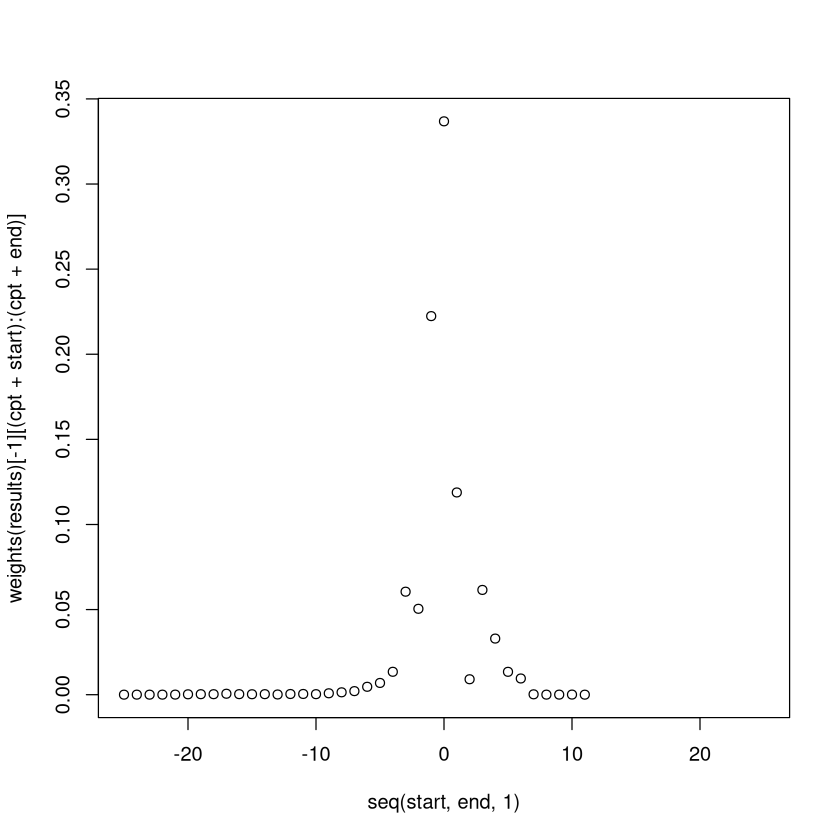

In [20]:
cpt = changepoint(results)$location
start <- -25
end <- 25
plot(seq(start,end,1),weights(results)[-1][(cpt+start):(cpt+end)])

#### Offline analysis - unknown variance

In [21]:
results <- bagel_uv_approximate(Y,feature_vector,prior,transform,p0,p,nu,iota,max_particles,threshold)

#### Check for a changepoint

In [22]:
changepoint(results)

$location
[1] 501

$detected
[1] 513

#### Visualise weight at tau = 0

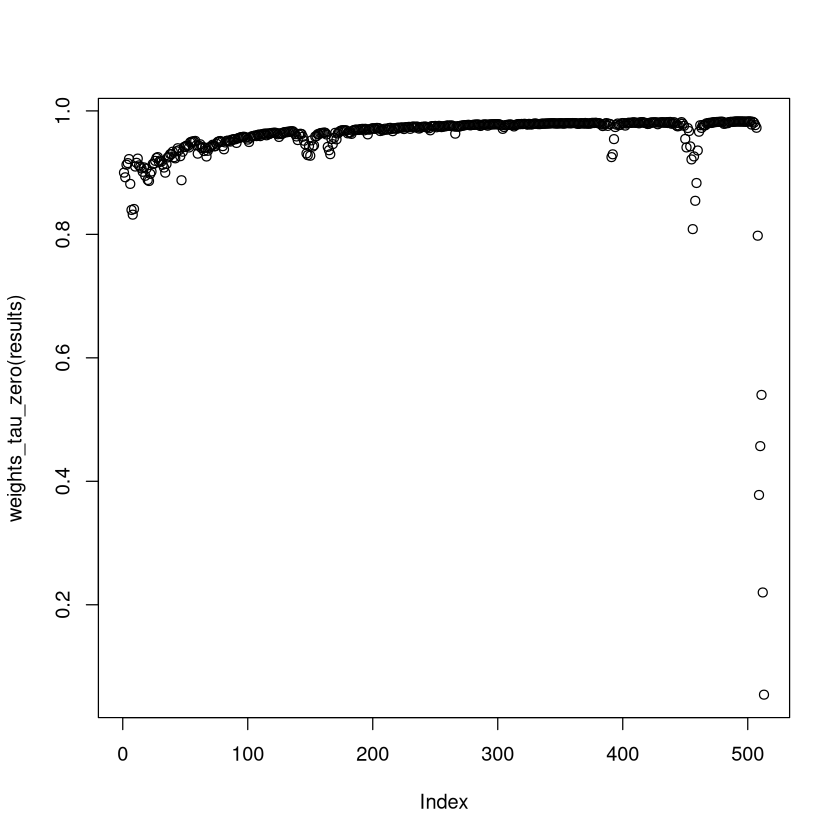

In [23]:
plot(weights_tau_zero(results))

#### Plot weights in region of changepoint

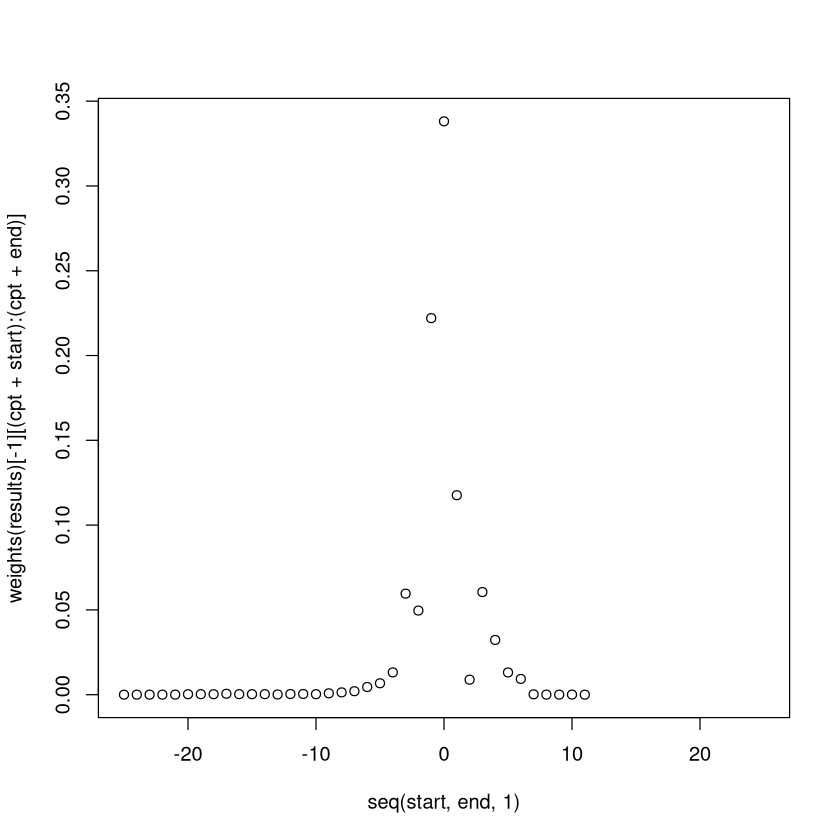

In [24]:
cpt = changepoint(results)$location
start <- -25
end <- 25
plot(seq(start,end,1),weights(results)[-1][(cpt+start):(cpt+end)])

### Example 3 - single change in mean different prior

#### Define new prior

In [25]:
prior <- function(t)
{
  mu1<-1;
  delta1<-1
  if(t == 1)
  {
    mu <- matrix(c(mu1),nc=1,nr=1)
    sigma <- delta1*diag(1)
    return(list("mu" = mu,"sigma" = sigma))
  }
  mu <- matrix(c(mu1,0),nc=1,nr=2)
  sigma <- delta1*matrix(c(1,-1,-1,2),nr=2,nc=2)
  return(list("mu" = mu,"sigma" = sigma))
}

#### Offline analysis - known variance

**Note** - _exact_ variation can be used since analysis is _univariate_ with _known variance_

In [26]:
results <- bagel_kv_exact(Y,feature_vector,prior,transform,p0,p,noise_sd,max_particles,threshold)

#### Check for a changepoint

In [27]:
changepoint(results)

$location
[1] 501

$detected
[1] 509

#### Visualise weight at tau = 0

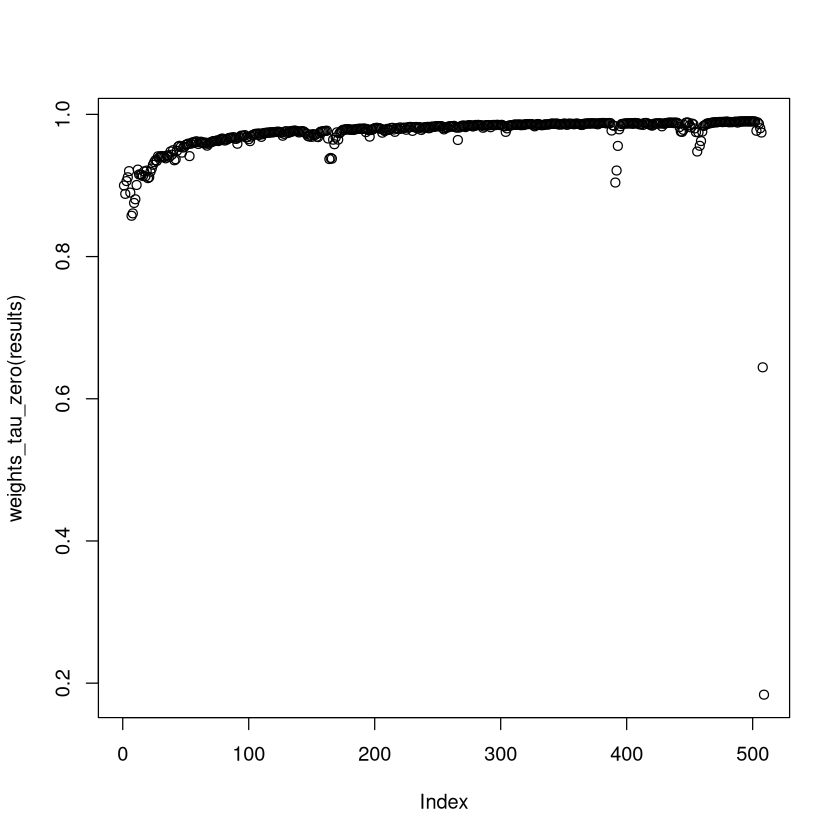

In [28]:
plot(weights_tau_zero(results))

#### Plot weights in region of changepoint

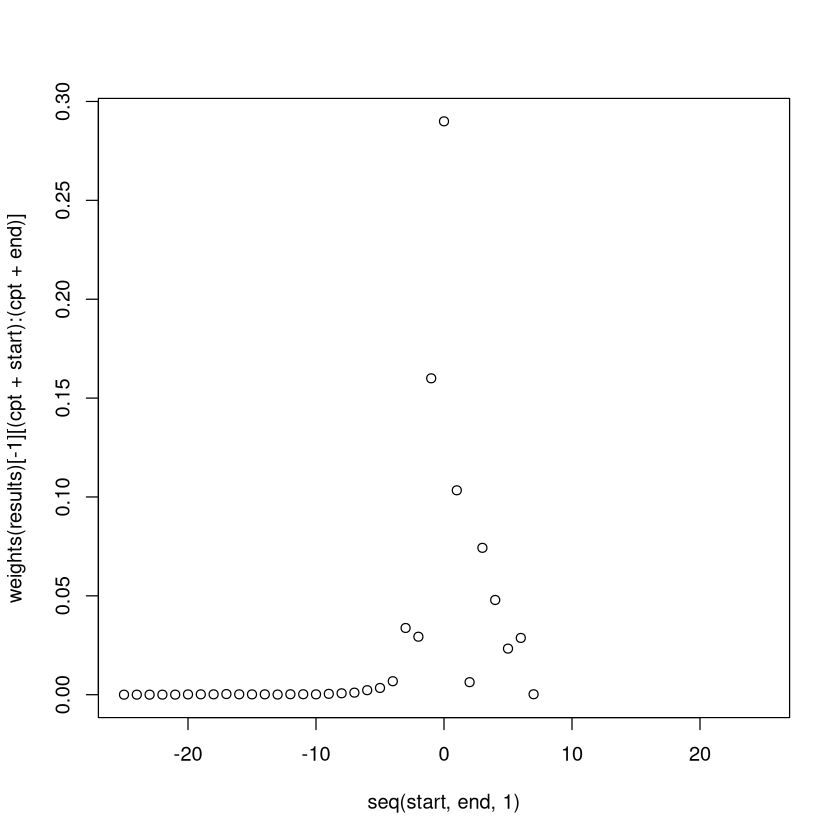

In [29]:
cpt = changepoint(results)$location
start <- -25
end <- 25
plot(seq(start,end,1),weights(results)[-1][(cpt+start):(cpt+end)])

#### Offline analysis - unknown variance

In [30]:
results <- bagel_uv_approximate(Y,feature_vector,prior,transform,p0,p,nu,iota,max_particles,threshold)

#### Check for a changepoint

In [31]:
changepoint(results)

$location
[1] 501

$detected
[1] 509

#### Visualise weight at tau = 0

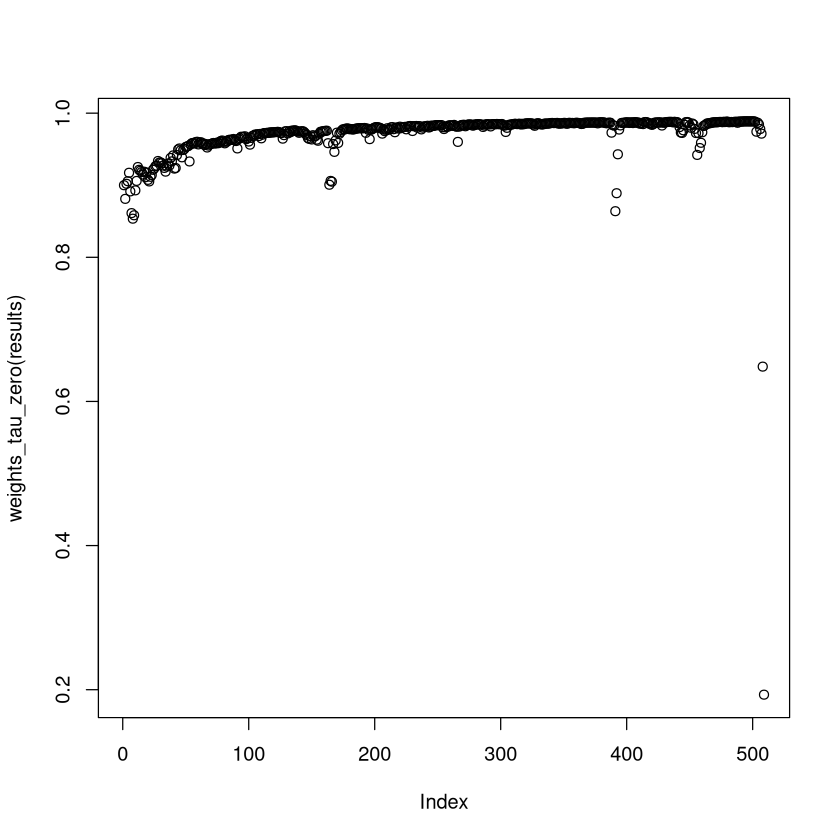

In [32]:
plot(weights_tau_zero(results))

#### Plot weights in region of changepoint

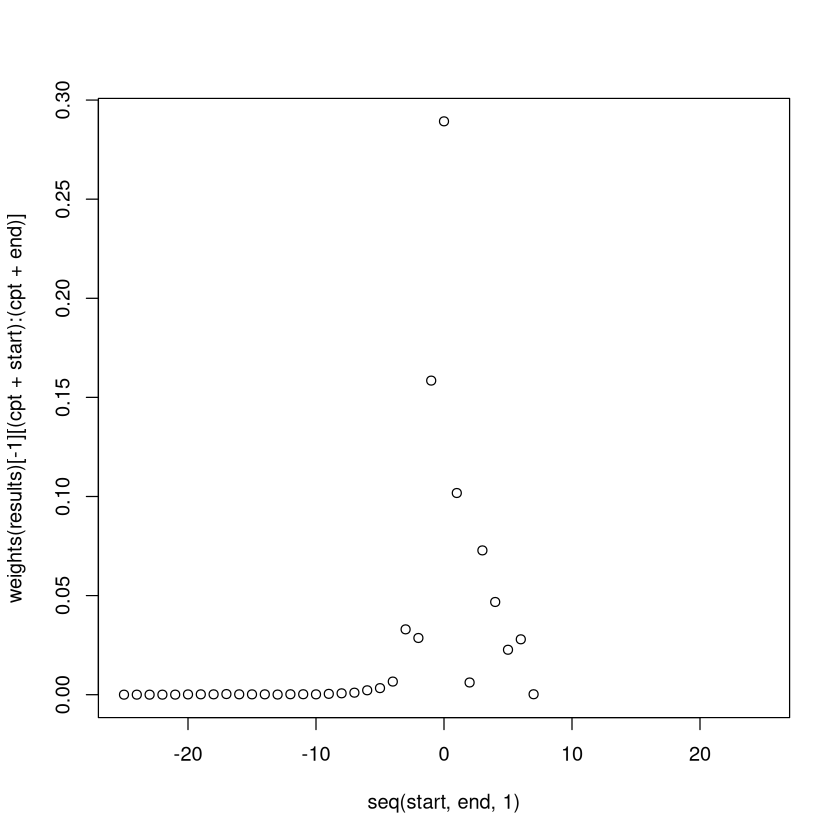

In [33]:
cpt = changepoint(results)$location
start <- -25
end <- 25
plot(seq(start,end,1),weights(results)[-1][(cpt+start):(cpt+end)])

## Using bagelR - 2 : Detecting Change in Slope

### Example 1 - no change

#### Generate some data - no change

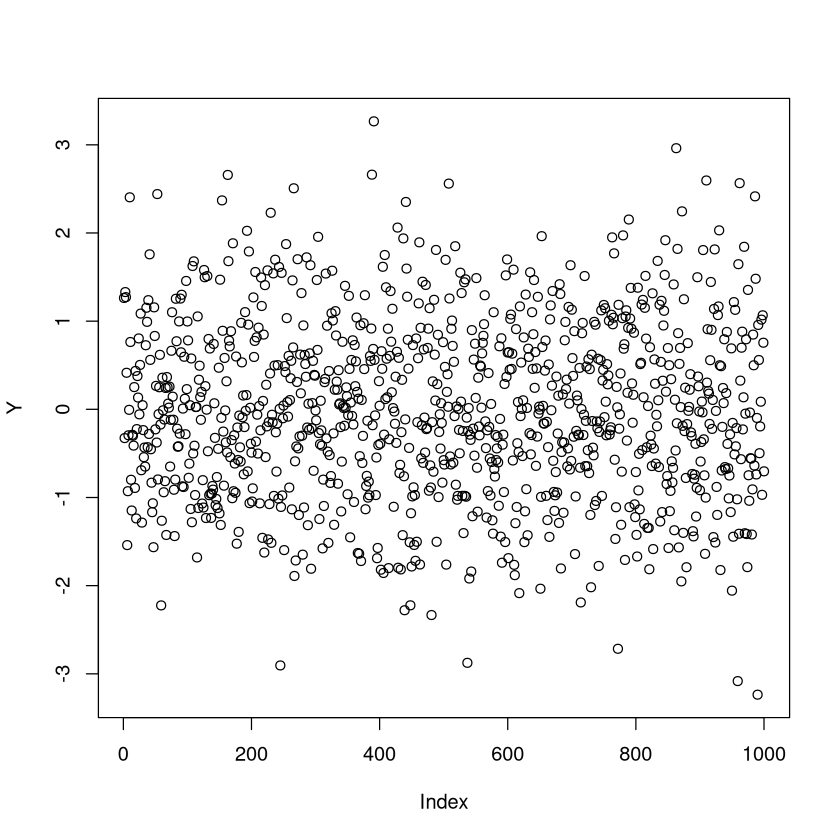

In [34]:
set.seed(0)
Y <- rnorm(1000,0,1)
plot(Y)

#### Define the feature vector function 

These functions for the **feature vector** and the **prior** correspeond to example 2 in "**Bagel : A Fast Baysian Online Changepoint Detection Algorithm for Linear Models**" *Fearnhead et al.*

In [35]:
feature_vector <- function(t,tau)
{
  if(tau == 0)
  {
     M <- matrix(c(0),nc=1,nr=2)	  
     M[1,1] <- 1
     M[2,1] <- t
     return(M)
  }
  else
  {
    M <- matrix(c(0),nc=1,nr=4)	  
    M[1,1] <- 1
    M[2,1] <- t
    if(t > tau)
    {
      M[3,1] <- 1
      M[4,1] <- t
    }
  return(M)
  }
}

#### Define the prior function

In [36]:
prior <- function(t)
{
  if(t == 1)
  {
     mu <- matrix(c(0),nc=1,nr=2)
     sigma <- diag(2)
     return(list("mu" = mu,"sigma" = sigma))
  }
  mu <- matrix(c(0),nc=1,nr=4)
  sigma <- diag(4)
  sigma[3,3] <- (t-1)*(t-1)
  sigma[4,3] <- sigma[3,4] <- -(t-1)
  return(list("mu" = mu,"sigma" = sigma))
}

#### Define the transformation function

In [37]:
transform <- function(tau)
{
	return(matrix(c(1,tau+1,1,tau+1,0,1,0,1),2,4,byrow=TRUE))
}

#### Set model parameters 

In [38]:
p <- 1.0;
p0 <- 0.9;
noise_sd <- 1.0;
max_particles <- 250
threshold <- 0.8

#### Offline analysis - known variance

In [39]:
results <- bagel_kv_approximate(Y,feature_vector,prior,transform,p0,p,noise_sd,max_particles,threshold)

#### Check for a changepoint

In [40]:
changepoint(results)

[1] NA

#### Visualise weight at tau = 0

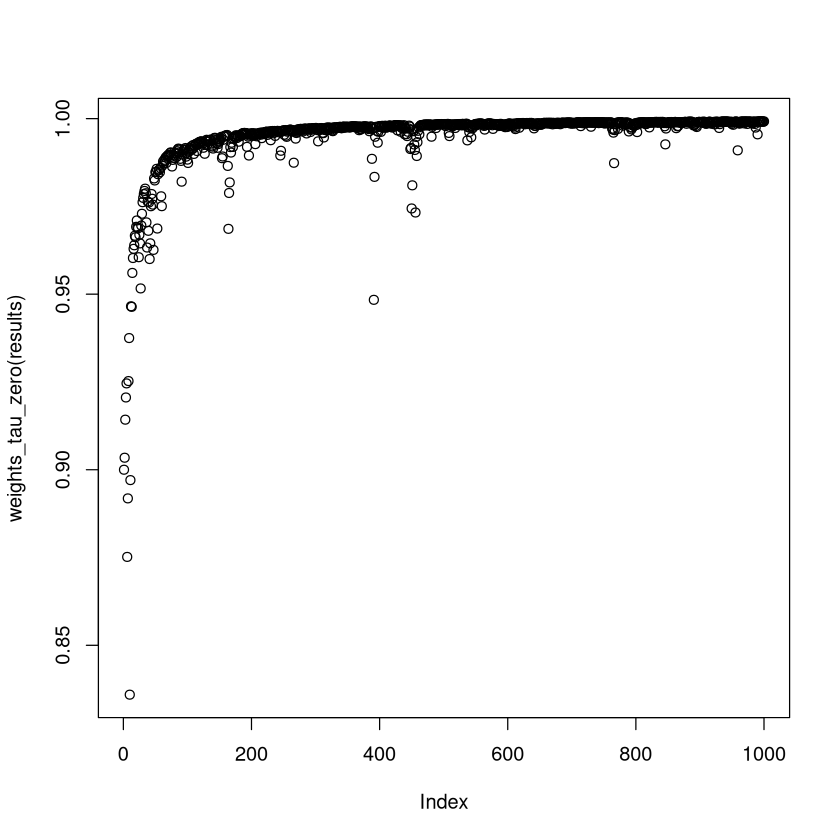

In [41]:
plot(weights_tau_zero(results))

#### Offline analysis - unknown variance

In [42]:
results <- bagel_uv_approximate(Y,feature_vector,prior,transform,p0,p,nu,iota,max_particles,threshold)

#### Check for a changepoint

In [43]:
changepoint(results)

[1] NA

#### Visualise weight at tau = 0

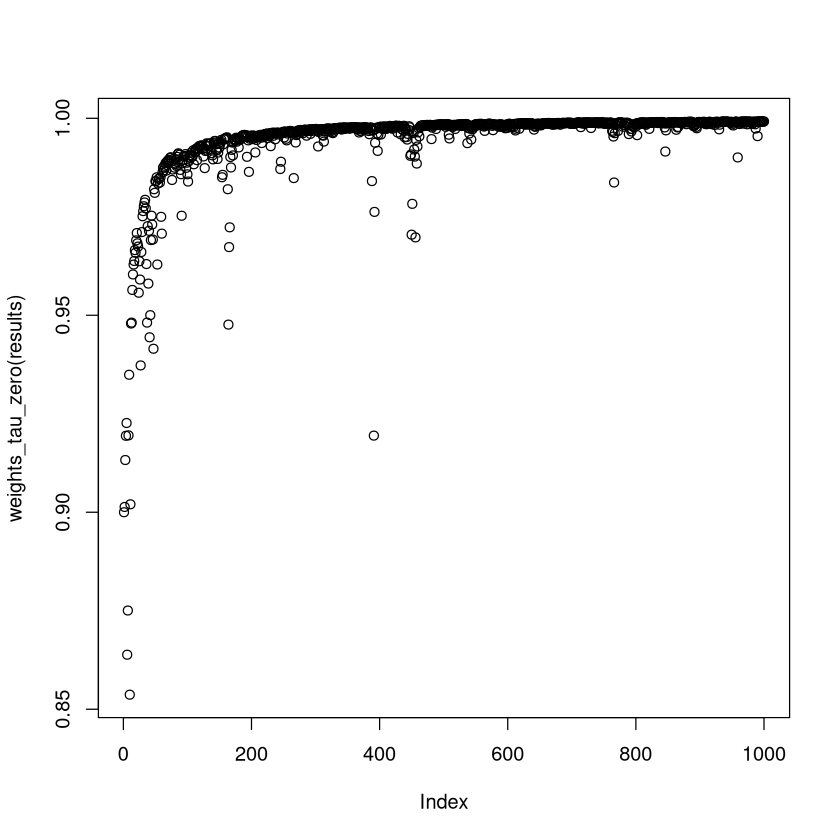

In [44]:
plot(weights_tau_zero(results))

### Example 2 - single change in slope

#### Generate data with change in slope at t = 1000

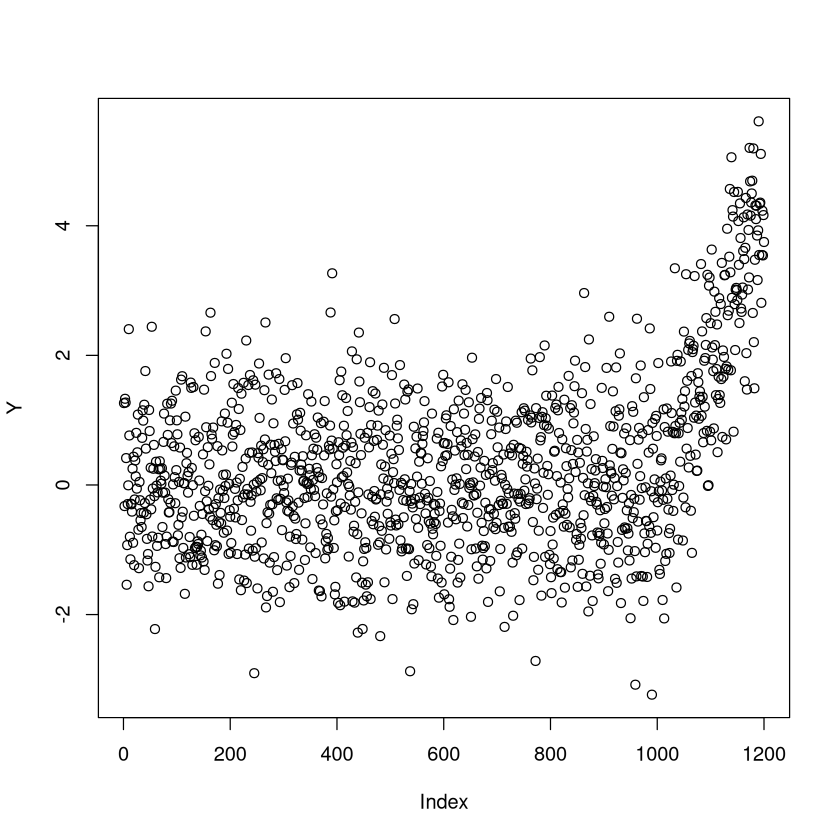

In [45]:
set.seed(0)
Y <- c(rnorm(1000,0,1),seq(1,200,1)/50 + rnorm(200,0,1))
plot(Y)

#### Offline analysis - known variance

In [46]:
results <- bagel_kv_approximate(Y,feature_vector,prior,transform,p0,p,noise_sd,max_particles,threshold)

#### Check for a changepoint

In [47]:
changepoint(results)

$location
[1] 1021

$detected
[1] 1058

#### Visualise weight at tau = 0

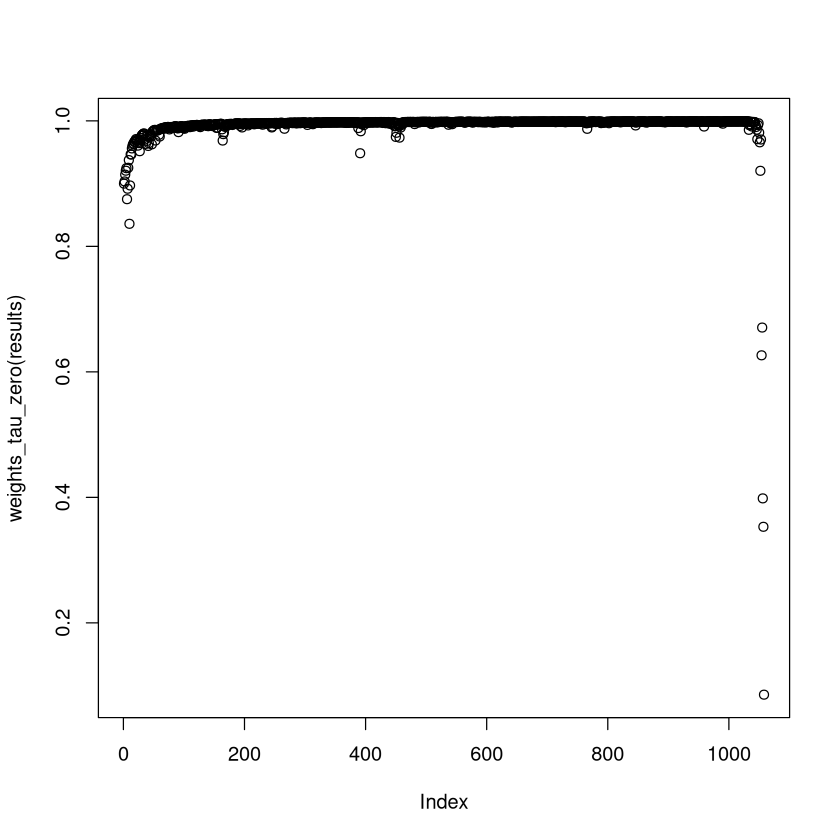

In [48]:
plot(weights_tau_zero(results))

#### Plot weights in region of changepoint

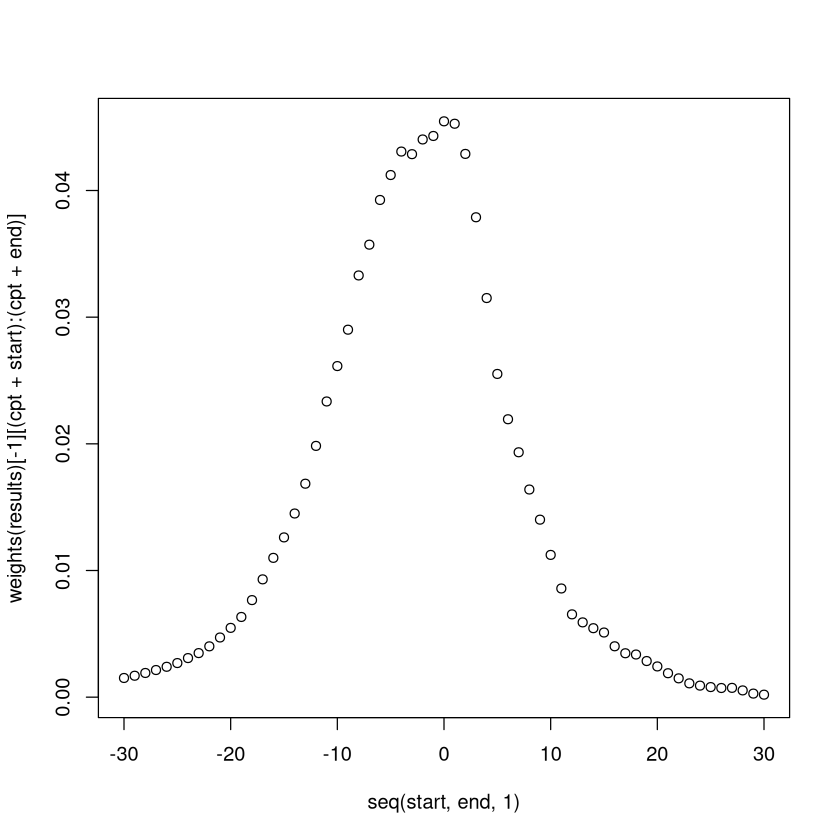

In [49]:
cpt = changepoint(results)$location
start <- -30
end <- 30
plot(seq(start,end,1),weights(results)[-1][(cpt+start):(cpt+end)])

#### Offline analysis - unknown variance

In [50]:
results <- bagel_uv_approximate(Y,feature_vector,prior,transform,p0,p,nu,iota,max_particles,threshold)

#### Check for a changepoint

In [51]:
changepoint(results)

$location
[1] 1021

$detected
[1] 1058

#### Visualise weight at tau = 0

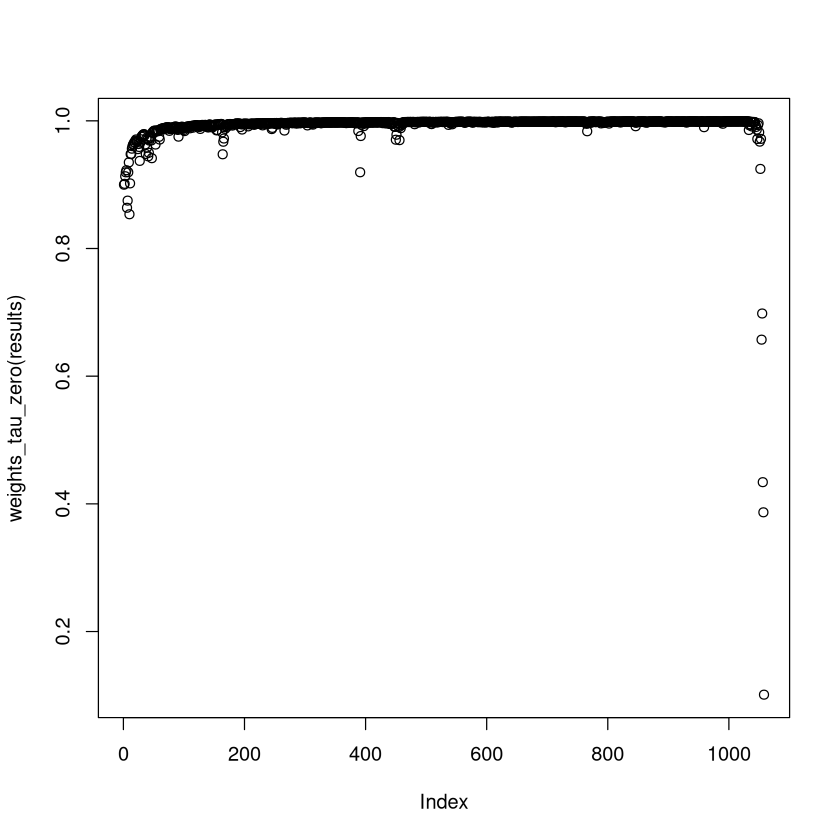

In [52]:
plot(weights_tau_zero(results))

#### Plot weights in region of changepoint

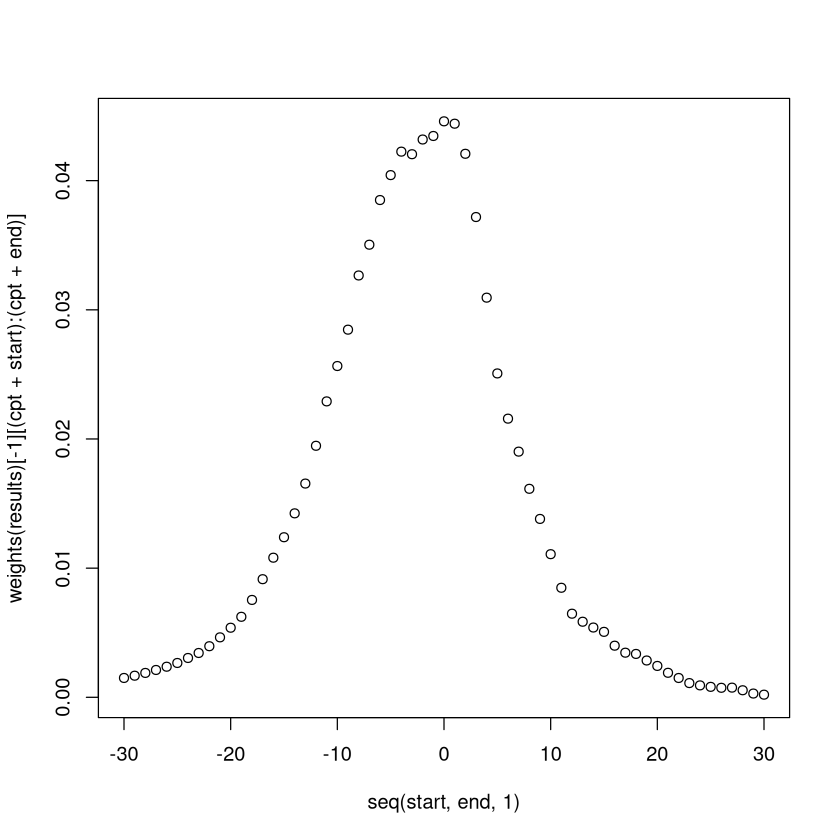

In [53]:
cpt = changepoint(results)$location
start <- -30
end <- 30
plot(seq(start,end,1),weights(results)[-1][(cpt+start):(cpt+end)])

### Other methods

### Get the taus

- Returns a vector of tau values for the active (unpruned) particles

In [54]:
taus(results)

[1]    0    1    2    3    4    5    6    8   10   11   12   18   21   29   33
 [16]   41   47   54   65   69   79   86  102  120  136  148  156  169  181  203
 [31]  222  242  263  280  291  303  318  334  349  357  374  387  396  409  421
 [46]  435  444  453  463  475  483  490  498  510  517  525  531  546  554  562
 [61]  570  576  583  590  598  610  616  624  634  644  654  664  672  679  684
 [76]  696  705  711  717  724  732  736  742  749  755  765  771  777  785  789
 [91]  795  801  805  809  813  817  821  825  829  833  837  841  845  850  853
[106]  857  863  868  871  875  877  881  883  885  887  889  891  895  897  899
[121]  901  904  906  909  911  913  916  918  920  922  924  926  928  930  932
[136]  934  936  938  940  942  944  946  948  949  951  953  954  955  956  957
[151]  958  959  960  961  962  963  964  965  966  967  968  969  970  971  972
[166]  973  974  975  976  977  978  979  980  981  982  983  984  985  986  987
[181]  988  989  990  991  992  993  994  995  996  997  998  999 1000 1001 1002
[196] 1003 1004 1005 1006 1007 1008 1009 1010 1011 1012 1013 1014 1015 1016 1017
[211] 1018 1019 1020 1021 1022 1023 1024 1025 1026 1027 1028 1029 1030 1031 1032
[226] 1033 1034 1035 1036 1037 1038 1039 1040 1041 1042 1043 1044 1045 1046 1047
[241] 1048 1049 1050 1051 1052 1053 1054 1055 1056 1057

### Get the ratios

- Returns a list of vectors containing the ratios for each active (unpruned) particle

In [55]:
ratios <- ratios(results)
ratios[[44]]

[1] 0.07619360 0.07714417 0.07700863 0.07799392 0.07557520 0.07659225
 [7] 0.07685004 0.07803862 0.07581242 0.07673238 0.07743619 0.07685820
[13] 0.07776439

### Get weights of active particles

- Returns a vector of weights for the currently active (unpruned) particles

In [56]:
active_weights(results)

[1] 1.010864e-01 6.140295e-06 4.595827e-06 3.195890e-06 2.711485e-06
  [6] 2.681282e-06 2.645503e-06 3.610342e-06 2.103225e-06 8.597274e-07
 [11] 8.155522e-07 3.298124e-06 9.334251e-07 1.556353e-06 5.367525e-07
 [16] 8.013190e-07 4.810820e-07 4.583573e-07 5.785558e-07 1.719980e-07
 [21] 3.599894e-07 2.112605e-07 4.022510e-07 3.687828e-07 2.748866e-07
 [26] 1.787728e-07 1.065346e-07 1.575822e-07 1.333421e-07 2.167527e-07
 [31] 1.704846e-07 1.684356e-07 1.662419e-07 1.312238e-07 8.339638e-08
 [36] 9.099792e-08 1.152604e-07 1.234360e-07 1.185429e-07 6.402176e-08
 [41] 1.427073e-07 1.109968e-07 8.004800e-08 1.195887e-07 1.177127e-07
 [46] 1.465819e-07 9.990003e-08 1.064658e-07 1.192647e-07 1.490956e-07
 [51] 1.028052e-07 9.239820e-08 1.085701e-07 1.722603e-07 1.055167e-07
 [56] 1.304049e-07 1.027183e-07 2.838790e-07 1.569443e-07 1.637530e-07
 [61] 1.742527e-07 1.363330e-07 1.643653e-07 1.675705e-07 1.923349e-07
 [66] 2.953757e-07 1.506337e-07 2.023635e-07 2.516586e-07 2.536276e-07
 [71] 2.645989e-07 2.782819e-07 2.322234e-07 2.092642e-07 1.518767e-07
 [76] 3.720912e-07 2.894573e-07 1.987377e-07 2.033449e-07 2.416853e-07
 [81] 2.838833e-07 1.434210e-07 2.138765e-07 2.512582e-07 2.147781e-07
 [86] 3.723417e-07 2.368301e-07 2.472361e-07 3.520111e-07 1.852841e-07
 [91] 3.049541e-07 3.433143e-07 2.439177e-07 2.578948e-07 2.756261e-07
 [96] 2.982022e-07 3.223284e-07 3.430834e-07 3.653374e-07 3.889690e-07
[101] 4.171003e-07 4.516609e-07 4.919037e-07 7.142242e-07 4.709213e-07
[106] 6.991684e-07 1.215298e-06 1.205134e-06 8.226581e-07 1.286279e-06
[111] 7.054984e-07 1.653707e-06 9.057765e-07 9.886739e-07 1.084009e-06
[116] 1.186399e-06 1.283342e-06 2.906069e-06 1.559188e-06 1.671692e-06
[121] 1.791031e-06 2.927955e-06 2.111247e-06 3.485434e-06 2.498827e-06
[126] 2.709278e-06 4.621482e-06 3.438157e-06 3.871420e-06 4.345441e-06
[131] 4.965843e-06 5.661552e-06 6.392651e-06 7.341975e-06 8.734279e-06
[136] 1.028728e-05 1.214032e-05 1.446032e-05 1.747587e-05 2.104413e-05
[141] 2.582699e-05 3.140621e-05 3.788233e-05 2.081637e-05 4.929001e-05
[146] 5.770380e-05 3.167890e-05 3.440692e-05 3.774808e-05 4.136146e-05
[151] 4.533133e-05 4.937425e-05 5.254064e-05 5.671701e-05 6.058466e-05
[156] 6.620533e-05 7.267758e-05 7.953357e-05 8.774078e-05 9.778473e-05
[161] 1.090123e-04 1.219870e-04 1.393630e-04 1.575295e-04 1.785077e-04
[166] 2.046053e-04 2.318091e-04 2.582943e-04 2.928756e-04 3.302393e-04
[171] 3.688624e-04 4.127571e-04 4.598027e-04 5.096814e-04 5.557663e-04
[176] 5.994581e-04 6.542926e-04 7.197446e-04 7.856922e-04 8.887138e-04
[181] 1.030029e-03 1.184957e-03 1.365598e-03 1.499631e-03 1.673991e-03
[186] 1.889039e-03 2.117752e-03 2.369710e-03 2.659398e-03 3.045919e-03
[191] 3.432779e-03 3.956578e-03 4.642951e-03 5.388016e-03 6.233960e-03
[196] 7.539716e-03 9.145875e-03 1.080986e-02 1.239351e-02 1.424293e-02
[201] 1.654889e-02 1.947331e-02 2.291022e-02 2.564825e-02 2.846253e-02
[206] 3.265778e-02 3.504023e-02 3.849842e-02 4.042817e-02 4.224490e-02
[211] 4.204514e-02 4.318457e-02 4.345737e-02 4.459113e-02 4.440821e-02
[216] 4.207873e-02 3.718225e-02 3.094053e-02 2.507456e-02 2.157336e-02
[221] 1.902106e-02 1.614216e-02 1.381079e-02 1.108262e-02 8.481361e-03
[226] 6.474107e-03 5.852398e-03 5.403258e-03 5.068511e-03 3.997372e-03
[231] 3.455813e-03 3.359304e-03 2.851498e-03 2.430343e-03 1.899171e-03
[236] 1.497074e-03 1.102782e-03 9.246667e-04 8.105814e-04 7.377615e-04
[241] 7.504446e-04 5.477067e-04 2.932601e-04 2.056444e-04 1.471509e-04
[246] 1.180297e-04 4.786017e-05 4.686300e-05 3.054292e-05 2.054856e-05

In [57]:
ratios(results)

[[1]]
[1] 1

[[2]]
[1] 1

[[3]]
[1] 1

[[4]]
[1] 1

[[5]]
[1] 1

[[6]]
[1] 1

[[7]]
[1] 1

[[8]]
[1] 0.5748499 0.4251501

[[9]]
[1] 0.5554493 0.4445507

[[10]]
[1] 1

[[11]]
[1] 1

[[12]]
[1] 0.2262436 0.1971232 0.1726732 0.1517076 0.1331414 0.1191109

[[13]]
[1] 0.3676055 0.3326226 0.2997718

[[14]]
[1] 0.1586643 0.1454043 0.1351897 0.1260712 0.1178503 0.1111793 0.1054065
[8] 0.1002345

[[15]]
[1] 0.2700102 0.2554271 0.2437417 0.2308210

[[16]]
[1] 0.1455316 0.1381372 0.1310413 0.1258302 0.1210647 0.1168940 0.1123490
[8] 0.1091520

[[17]]
[1] 0.1782571 0.1743087 0.1683867 0.1645844 0.1595894 0.1548737

[[18]]
[1] 0.1554199 0.1508987 0.1463013 0.1427570 0.1378070 0.1346756 0.1321405

[[19]]
 [1] 0.10151388 0.09973053 0.09687453 0.09547193 0.09328401 0.09146880
 [7] 0.08917560 0.08582365 0.08405076 0.08226959 0.08033671

[[20]]
[1] 0.2581101 0.2519259 0.2480661 0.2418979

[[21]]
 [1] 0.10885532 0.10637928 0.10470127 0.10257310 0.10145827 0.09932292
 [7] 0.09644219 0.09507629 0.09321005 0.09198131

[[22]]
[1] 0.1512427 0.1481997 0.1455989 0.1412428 0.1393435 0.1381667 0.1362056

[[23]]
 [1] 0.06928027 0.06846919 0.06753273 0.06637751 0.06587052 0.06383334
 [7] 0.06340088 0.06283398 0.06181787 0.06142693 0.05967042 0.05933202
[13] 0.05830351 0.05817413 0.05678822 0.05688847

[[24]]
 [1] 0.06019193 0.06012619 0.05916179 0.05907085 0.05818730 0.05801310
 [7] 0.05651239 0.05653744 0.05627263 0.05448251 0.05446658 0.05421316
[13] 0.05334772 0.05330537 0.05191854 0.05186036 0.05118352 0.05114862

[[25]]
 [1] 0.06611342 0.06607251 0.06582066 0.06501357 0.06484205 0.06381185
 [7] 0.06374780 0.06352851 0.06128860 0.06125835 0.06102872 0.06014747
[13] 0.06025853 0.05903940 0.05909147 0.05893710

[[26]]
 [1] 0.08650441 0.08645745 0.08587899 0.08559191 0.08403727 0.08375652
 [7] 0.08327659 0.08296493 0.08071013 0.08016975 0.08063603 0.08001602

[[27]]
[1] 0.1270367 0.1261095 0.1274613 0.1260687 0.1239932 0.1230778 0.1233823
[8] 0.1228705

[[28]]
 [1] 0.07917619 0.07884471 0.07938850 0.07903397 0.07810917 0.07791615
 [7] 0.07766226 0.07525689 0.07551620 0.07552216 0.07431161 0.07461575
[13] 0.07464644

[[29]]
 [1] 0.08507685 0.08539623 0.08465744 0.08504601 0.08328172 0.08362612
 [7] 0.08284842 0.08316411 0.08183824 0.08202312 0.08157729 0.08146445

[[30]]
 [1] 0.04704574 0.04713341 0.04732128 0.04758293 0.04752448 0.04692340
 [7] 0.04696652 0.04695591 0.04555763 0.04566302 0.04569613 0.04562104
[13] 0.04583341 0.04400968 0.04422328 0.04390197 0.04414203 0.04369809
[19] 0.04392661 0.04329431 0.04346688 0.04351226

[[31]]
 [1] 0.05382893 0.05413109 0.05377431 0.05410906 0.05355797 0.05390301
 [7] 0.05408363 0.05279185 0.05309953 0.05281217 0.05310290 0.05166109
[13] 0.05196776 0.05166815 0.05197674 0.05070641 0.05100649 0.05075140
[19] 0.05106749

[[32]]
 [1] 0.05129811 0.05162865 0.05136749 0.05168710 0.05068417 0.05102676
 [7] 0.05125582 0.04978798 0.05009530 0.04982813 0.05016659 0.04969513
[13] 0.05002759 0.04892961 0.04927274 0.04943222 0.04822481 0.04857881
[19] 0.04833630 0.04867669

[[33]]
 [1] 0.04839778 0.04871957 0.04848479 0.04885734 0.04840496 0.04880327
 [7] 0.04739234 0.04779492 0.04800736 0.04767474 0.04807689 0.04695427
[13] 0.04735718 0.04708808 0.04749745 0.04703016 0.04743412 0.04619002
[19] 0.04659300 0.04642199 0.04681977

[[34]]
 [1] 0.05949953 0.05998602 0.06027310 0.05970883 0.06009906 0.05878226
 [7] 0.05929605 0.05967567 0.05791734 0.05838456 0.05794428 0.05860052
[13] 0.05806587 0.05856177 0.05734189 0.05777040 0.05809285

[[35]]
 [1] 0.09091331 0.09168845 0.09146183 0.09228134 0.09032893 0.09119144
 [7] 0.09166496 0.08959234 0.09042430 0.08981442 0.09063868

[[36]]
 [1] 0.08379723 0.08444707 0.08382143 0.08466531 0.08277426 0.08353965
 [7] 0.08296149 0.08378215 0.08206721 0.08278904 0.08236055 0.08299460

[[37]]
 [1] 0.06768246 0.06789332 0.06758496 0.06798608 0.06648364 0.06697350
 [7] 0.06747314 0.06575401 0.06641572 0.06605862 0.06675421 0.06523149
[13] 0.06592526 0.06555232 0.06623126

[[38]]
 [1] 0.06244475 0